### Setup: Import Dependencies
Run the cell below to import the relevant dependencies.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
import functools

### Part 1: CMA-ES
Implement CMA-ES below.

In [2]:
def cmaes(fn, dim, num_iter=10):
  """Optimizes a given function using CMA-ES.

  Args:
    fn: A function that takes as input a vector and outputs a scalar value.
    dim: (int) The dimension of the vector that fn expects as input.
    num_iter: (int) Number of iterations to run CMA-ES.

  Returns:
    mu_vec: An array of size [num_iter, dim] storing the value of mu at each
      iteration.
    best_sample_vec: A list of length [num_iter] storing the function value
      for the best sample from each iteration of CMA-ES.
    mean_sample_vec: A list of length [num_iter] storing the average function
      value across samples from each iteration of CMA-ES.
  """
  # Hyperparameters
  sigma = 10
  population_size = 100
  p_keep = 0.10  # Fraction of population to keep
  noise = 0.25  # Noise added to covariance to prevent it from going to 0.

  # Initialize the mean and covariance
  mu = np.zeros(dim)
  cov = sigma**2 * np.eye(dim)

  mu_vec = []
  best_sample_vec = []
  mean_sample_vec = []

  elite_size = int(population_size * p_keep)

  for t in range(num_iter):
    # WRITE CODE HERE
    # Sample population from multivariate Gaussian
    population = np.random.multivariate_normal(mu, cov, size=population_size)

    # Evaluate fitness for each sample
    fitness_values = np.array([fn(sample) for sample in population])

    # Sort population by fitness (descending order since we're maximizing)
    sorted_indices = np.argsort(fitness_values)[::-1]
    elite_indices = sorted_indices[:elite_size]

    # Get elite samples
    elite_samples = population[elite_indices]

    # Update mean: average of elite samples
    mu = np.mean(elite_samples, axis=0)

    # Update covariance: covariance of elite samples + noise
    cov = np.cov(elite_samples.T) + noise * np.eye(dim)

    # Store results for this iteration
    mu_vec.append(mu.copy())
    best_sample_vec.append(fitness_values[sorted_indices[0]])
    mean_sample_vec.append(np.mean(fitness_values))

  return mu_vec, best_sample_vec, mean_sample_vec

In the cell below, we've defined a simply function:
$$f(x) = -\|x - x^*\|_2^2 \quad \text{where} \quad x^* = [65, 49].$$
This function is optimized when $x = x^*$. Run your implementation of CMA-ES on this function, confirming that you get the correct solution.

In [3]:
def test_fn(x):
  goal = np.array([65, 49])
  return -np.sum((x - goal)**2)

mu_vec, best_sample_vec, mean_sample_vec = cmaes(test_fn, dim=2, num_iter=100)

Run the following cell to visualize CMA-ES.

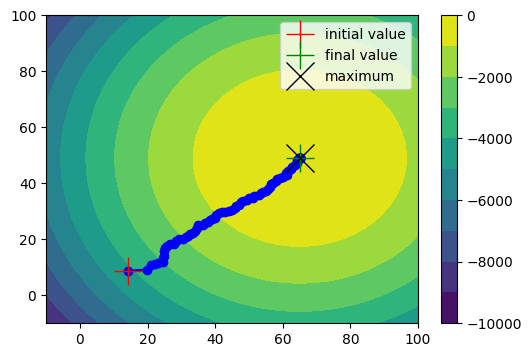

In [4]:
x = np.stack(np.meshgrid(np.linspace(-10, 100, 30), np.linspace(-10, 100, 30)), axis=-1)
fn_value = [test_fn(xx) for xx in x.reshape((-1, 2))]
fn_value = np.array(fn_value).reshape((30, 30))
plt.figure(figsize=(6, 4))
plt.contourf(x[:, :, 0], x[:, :, 1], fn_value, levels=10)
plt.colorbar()
mu_vec = np.array(mu_vec)
plt.plot(mu_vec[:, 0], mu_vec[:, 1], 'b-o')
plt.plot([mu_vec[0, 0]], [mu_vec[0, 1]], 'r+', ms=20, label='initial value')
plt.plot([mu_vec[-1, 0]], [mu_vec[-1, 1]], 'g+', ms=20, label='final value')
plt.plot([65], [49], 'kx', ms=20, label='maximum')
plt.legend()
plt.show()

Next, you will apply CMA-ES to a more complicating: maximizing the expected reward of a RL agent. The policy takes action LEFT with probability:
$$\pi(a = \text{LEFT} \mid s) = s \cdot w + b,$$
where $w \in \mathbb{R}^4$ and $b \in \mathbb{R}$ are parameters that you will optimize with CMA-ES. In the cell below, define a function that takes as input a single vector $x = (w, b)$ and the environment and returns the total (undiscounted) reward from one episode.

In [5]:
def _sigmoid(x):
  return 1 / (1 + np.exp(-x))

def _get_action(s, params):
  w = params[:4]
  b = params[4]
  p_left = _sigmoid(w @ s + b)
  a = np.random.choice(2, p=[p_left, 1 - p_left])
  return a

def rl_fn(params, env):
  assert len(params) == 5
  ## WRITE CODE HERE
  # Reset environment
  state, _ = env.reset()

  total_rewards = 0
  done = False
  truncated = False

  # Run one episode
  while not (done or truncated):
    # Get action using the policy
    action = _get_action(state, params)

    # Take step in environment
    state, reward, done, truncated, _ = env.step(action)

    # Accumulate rewards
    total_rewards += reward

  return total_rewards


The cell below applies your CMA-ES implementation to the RL objective you've defined in the cell above.

In [6]:
env = gym.make('CartPole-v0')
fn_with_env = functools.partial(rl_fn, env=env)
mu_vec, best_sample_vec, mean_sample_vec = cmaes(fn_with_env, dim=5, num_iter=10)

/usr/local/lib/python3.12/dist-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment CartPole-v0 is out of date. You should consider upgrading to version `v1`.
  logger.deprecation(


In [7]:
# Part 2: Evaluate test policies 1000 times and report average total reward
env_test = gym.make('CartPole-v0')

test_policies = [
    np.array([-1, -1, -1, -1, -1]),
    np.array([1, 0, 1, 0, 1]),
    np.array([0, 1, 2, 3, 4])
]

print("Evaluating test policies (1000 episodes each):")
for i, policy in enumerate(test_policies):
    rewards = []
    for _ in range(1000):
        reward = rl_fn(policy, env_test)
        rewards.append(reward)
    avg_reward = np.mean(rewards)
    print(f"Policy {i+1}: x = {policy}, Average reward: {avg_reward:.1f}")

Evaluating test policies (1000 episodes each):
Policy 1: x = [-1 -1 -1 -1 -1], Average reward: 15.6
Policy 2: x = [1 0 1 0 1], Average reward: 14.3
Policy 3: x = [0 1 2 3 4], Average reward: 9.4



Running CMA-ES on CartPole environment...

Final best reward: 200.00
Final mean reward: 196.47


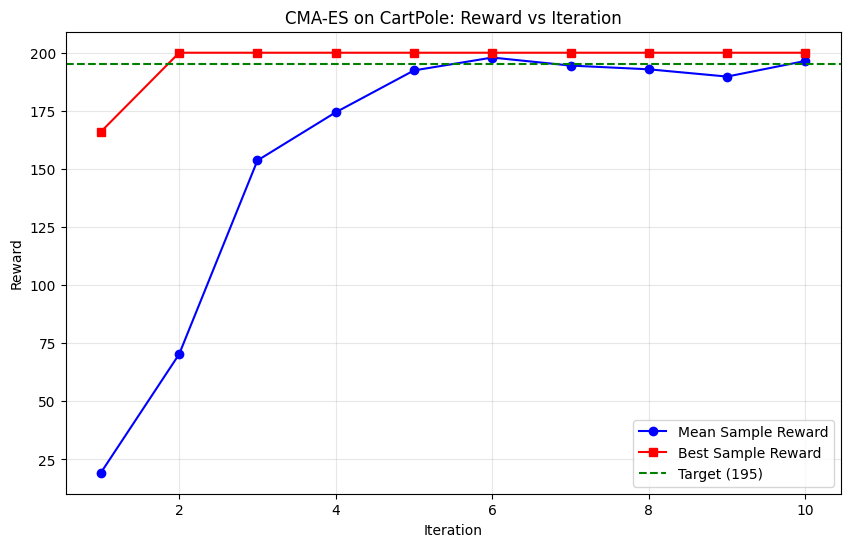


Best sample rewards per iteration: [np.float64(166.0), np.float64(200.0), np.float64(200.0), np.float64(200.0), np.float64(200.0), np.float64(200.0), np.float64(200.0), np.float64(200.0), np.float64(200.0), np.float64(200.0)]
Mean sample rewards per iteration: [np.float64(19.31), np.float64(70.31), np.float64(153.65), np.float64(174.37), np.float64(192.39), np.float64(197.92), np.float64(194.47), np.float64(192.86), np.float64(189.74), np.float64(196.47)]


In [8]:
# Part 3: Run CMA-ES on RL objective and plot results
print("\nRunning CMA-ES on CartPole environment...")
env = gym.make('CartPole-v0')
fn_with_env = functools.partial(rl_fn, env=env)
mu_vec_rl, best_sample_vec_rl, mean_sample_vec_rl = cmaes(fn_with_env, dim=5, num_iter=10)

print(f"\nFinal best reward: {best_sample_vec_rl[-1]:.2f}")
print(f"Final mean reward: {mean_sample_vec_rl[-1]:.2f}")

# Plot mean and best sample rewards across iterations
plt.figure(figsize=(10, 6))
iterations = np.arange(1, len(best_sample_vec_rl) + 1)
plt.plot(iterations, mean_sample_vec_rl, 'b-o', label='Mean Sample Reward')
plt.plot(iterations, best_sample_vec_rl, 'r-s', label='Best Sample Reward')
plt.axhline(y=195, color='g', linestyle='--', label='Target (195)')
plt.xlabel('Iteration')
plt.ylabel('Reward')
plt.title('CMA-ES on CartPole: Reward vs Iteration')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"\nBest sample rewards per iteration: {best_sample_vec_rl}")
print(f"Mean sample rewards per iteration: {mean_sample_vec_rl}")